# Dataset Exploration & Organization
## ICT3212 - Introduction to Intelligent Systems
### Facial Emotion Detection System (Inflators)

This notebook covers:
1. **Dataset Overview** — Source, number of classes, and class labels.
2. **Organizing Images into Class-Wise Folders** — Converting CSV pixel data into actual image files.
3. **Loading Images** — Using appropriate libraries to load the organized dataset.
4. **Verifying Dataset Size & Balance** — Class distribution analysis with visualizations.
5. **Sample Images** — Displaying sample images from each class.

---
## 1. Dataset Overview

| Property | Details |
|---|---|
| **Dataset Name** | FER-2013 (Facial Expression Recognition 2013) |
| **Source** | [Kaggle - Challenges in Representation Learning](https://www.kaggle.com/c/challenges-in-representation-learning-facial-expression-recognition-challenge/data) |
| **Classification Type** | **Multi-class** classification |
| **Original Classes (7)** | 0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral |
| **Used Classes (6)** | Angry, Fear, Happy, Sad, Surprise, Neutral *(Disgust removed due to very low sample count)* |
| **Image Size** | 48 × 48 pixels |
| **Color** | Grayscale (1 channel) |
| **Format** | CSV file with pixel values as space-separated strings |

---
## 2. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 3. Load Raw CSV Data

In [2]:
# Load the FER-2013 dataset
CSV_PATH = 'data/fer2013.csv'
df = pd.read_csv(CSV_PATH)

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nFirst 5 rows:')
df.head()

Dataset Shape: (35887, 3)
Columns: ['emotion', 'pixels', 'Usage']

First 5 rows:


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [3]:
# Original class distribution (all 7 classes)
ORIGINAL_LABELS = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

print('=== Original Class Distribution (7 Classes) ===')
for label_id, count in df['emotion'].value_counts().sort_index().items():
    print(f'  {label_id} ({ORIGINAL_LABELS[label_id]}): {count} images')
print(f'  Total: {len(df)} images')
print(f'\nNote: Disgust class has very few samples, so we remove it for better model performance.')

=== Original Class Distribution (7 Classes) ===
  0 (Angry): 4953 images
  1 (Disgust): 547 images
  2 (Fear): 5121 images
  3 (Happy): 8989 images
  4 (Sad): 6077 images
  5 (Surprise): 4002 images
  6 (Neutral): 6198 images
  Total: 35887 images

Note: Disgust class has very few samples, so we remove it for better model performance.


In [4]:
# Filter out Disgust (label 1)
df_filtered = df[df['emotion'] != 1].copy()

# Remap labels to 0-5 for our 6-class problem
LABEL_MAP = {0: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
EMOTION_LABELS = {0: 'Angry', 1: 'Fear', 2: 'Happy', 3: 'Sad', 4: 'Surprise', 5: 'Neutral'}

df_filtered['emotion'] = df_filtered['emotion'].map(LABEL_MAP)

print('=== Filtered Class Distribution (6 Classes) ===')
for label_id, count in df_filtered['emotion'].value_counts().sort_index().items():
    print(f'  {label_id} ({EMOTION_LABELS[label_id]}): {count} images')
print(f'  Total: {len(df_filtered)} images')

=== Filtered Class Distribution (6 Classes) ===
  0 (Angry): 4953 images
  1 (Fear): 5121 images
  2 (Happy): 8989 images
  3 (Sad): 6077 images
  4 (Surprise): 4002 images
  5 (Neutral): 6198 images
  Total: 35340 images


---
## 4. Organize Images into Class-Wise Folders

The FER-2013 dataset comes as a CSV with pixel values encoded as strings. We will convert each row into a 48×48 grayscale `.png` image and save it into class-wise folders:

```
data/
├── organized/
│   ├── Angry/
│   ├── Fear/
│   ├── Happy/
│   ├── Sad/
│   ├── Surprise/
│   └── Neutral/
```

In [5]:
# Create class-wise folders
OUTPUT_DIR = 'data/organized'

for label_id, label_name in EMOTION_LABELS.items():
    folder_path = os.path.join(OUTPUT_DIR, label_name)
    os.makedirs(folder_path, exist_ok=True)

print('Created folder structure:')
for label_name in EMOTION_LABELS.values():
    print(f'  data/organized/{label_name}/')

Created folder structure:
  data/organized/Angry/
  data/organized/Fear/
  data/organized/Happy/
  data/organized/Sad/
  data/organized/Surprise/
  data/organized/Neutral/


In [6]:
# Convert CSV pixel data to images and save into class-wise folders
print('Converting CSV pixel data to images...')
print('This may take a few minutes...\n')

counters = {label: 0 for label in EMOTION_LABELS.values()}

for idx, row in df_filtered.iterrows():
    emotion_id = row['emotion']
    emotion_name = EMOTION_LABELS[emotion_id]
    
    # Convert pixel string to numpy array
    pixels = np.array([int(p) for p in row['pixels'].split(' ')], dtype=np.uint8)
    image = pixels.reshape(48, 48)
    
    # Save image
    counters[emotion_name] += 1
    filename = f'{emotion_name}_{counters[emotion_name]:05d}.png'
    filepath = os.path.join(OUTPUT_DIR, emotion_name, filename)
    cv2.imwrite(filepath, image)

print('Image conversion complete!')
print('\nImages saved per class:')
for label, count in counters.items():
    print(f'  {label}: {count} images')
print(f'  Total: {sum(counters.values())} images')

Converting CSV pixel data to images...
This may take a few minutes...

Image conversion complete!

Images saved per class:
  Angry: 4953 images
  Fear: 5121 images
  Happy: 8989 images
  Sad: 6077 images
  Surprise: 4002 images
  Neutral: 6198 images
  Total: 35340 images


---
## 5. Load Images Using Appropriate Libraries

We demonstrate loading the organized images using **OpenCV**, **PIL (Pillow)**, and **Matplotlib**.

In [7]:
# Method 1: Load using OpenCV
print('=== Method 1: Loading with OpenCV ===')
sample_path = os.path.join(OUTPUT_DIR, 'Happy', 'Happy_00001.png')
img_cv2 = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
print(f'Image shape (OpenCV): {img_cv2.shape}')
print(f'Data type: {img_cv2.dtype}')
print(f'Min pixel: {img_cv2.min()}, Max pixel: {img_cv2.max()}')

# Method 2: Load using PIL (Pillow)
print('\n=== Method 2: Loading with PIL (Pillow) ===')
img_pil = Image.open(sample_path)
print(f'Image size (PIL): {img_pil.size}')
print(f'Image mode: {img_pil.mode}')

# Method 3: Load using Matplotlib
print('\n=== Method 3: Loading with Matplotlib ===')
img_mpl = mpimg.imread(sample_path)
print(f'Image shape (Matplotlib): {img_mpl.shape}')
print(f'Data type: {img_mpl.dtype}')

=== Method 1: Loading with OpenCV ===
Image shape (OpenCV): (48, 48)
Data type: uint8
Min pixel: 0, Max pixel: 234

=== Method 2: Loading with PIL (Pillow) ===
Image size (PIL): (48, 48)
Image mode: L

=== Method 3: Loading with Matplotlib ===
Image shape (Matplotlib): (48, 48)
Data type: float32


In [8]:
# Load all images from organized folders and count them
print('=== Loading All Images from Class-Wise Folders ===')

class_counts = {}
all_images = []
all_labels = []

for label_id, label_name in EMOTION_LABELS.items():
    folder = os.path.join(OUTPUT_DIR, label_name)
    files = [f for f in os.listdir(folder) if f.endswith('.png')]
    class_counts[label_name] = len(files)
    
    # Load a subset for demonstration (loading all would use too much RAM)
    for f in files[:100]:  # Load first 100 per class for demo
        img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
        all_images.append(img)
        all_labels.append(label_id)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f'Loaded sample shape: {all_images.shape}')
print(f'Labels shape: {all_labels.shape}')
print(f'\nImages per class folder:')
for label, count in class_counts.items():
    print(f'  {label}: {count}')
print(f'  Total images in dataset: {sum(class_counts.values())}')

=== Loading All Images from Class-Wise Folders ===
Loaded sample shape: (600, 48, 48)
Labels shape: (600,)

Images per class folder:
  Angry: 4953
  Fear: 5121
  Happy: 8989
  Sad: 6077
  Surprise: 4002
  Neutral: 6198
  Total images in dataset: 35340


---
## 6. Verify Dataset Size and Balance

In [9]:
# Dataset size summary
total_images = sum(class_counts.values())

print('=' * 60)
print('DATASET SIZE & BALANCE VERIFICATION')
print('=' * 60)
print(f'\nTotal number of images : {total_images}')
print(f'Number of classes      : {len(class_counts)} (Multi-class)')
print(f'Image dimensions       : 48 x 48 pixels')
print(f'Color mode             : Grayscale (1 channel)')
print(f'\n{"Class":<15} {"Count":>8} {"Percentage":>12} {"Bar"}')
print('-' * 60)
for label, count in class_counts.items():
    pct = (count / total_images) * 100
    bar = '█' * int(pct)
    print(f'{label:<15} {count:>8} {pct:>10.1f}%  {bar}')
print('-' * 60)
print(f'{"TOTAL":<15} {total_images:>8} {100.0:>10.1f}%')

DATASET SIZE & BALANCE VERIFICATION

Total number of images : 35340
Number of classes      : 6 (Multi-class)
Image dimensions       : 48 x 48 pixels
Color mode             : Grayscale (1 channel)

Class              Count   Percentage Bar
------------------------------------------------------------
Angry               4953       14.0%  ██████████████
Fear                5121       14.5%  ██████████████
Happy               8989       25.4%  █████████████████████████
Sad                 6077       17.2%  █████████████████
Surprise            4002       11.3%  ███████████
Neutral             6198       17.5%  █████████████████
------------------------------------------------------------
TOTAL              35340      100.0%


In [10]:
# Balance analysis
counts = list(class_counts.values())
mean_count = np.mean(counts)
std_count = np.std(counts)
max_count = max(counts)
min_count = min(counts)
imbalance_ratio = max_count / min_count

print('=== Balance Analysis ===')
print(f'Mean samples per class  : {mean_count:.0f}')
print(f'Std deviation           : {std_count:.0f}')
print(f'Largest class           : {max(class_counts, key=class_counts.get)} ({max_count})')
print(f'Smallest class          : {min(class_counts, key=class_counts.get)} ({min_count})')
print(f'Imbalance ratio         : {imbalance_ratio:.2f}x')

if imbalance_ratio > 3:
    print('\n⚠️  Dataset is significantly IMBALANCED. Consider data augmentation or class weighting.')
elif imbalance_ratio > 1.5:
    print('\n⚠️  Dataset has moderate imbalance. Some classes have more samples than others.')
else:
    print('\n✅  Dataset is relatively balanced.')

=== Balance Analysis ===
Mean samples per class  : 5890
Std deviation           : 1569
Largest class           : Happy (8989)
Smallest class          : Surprise (4002)
Imbalance ratio         : 2.25x

⚠️  Dataset has moderate imbalance. Some classes have more samples than others.


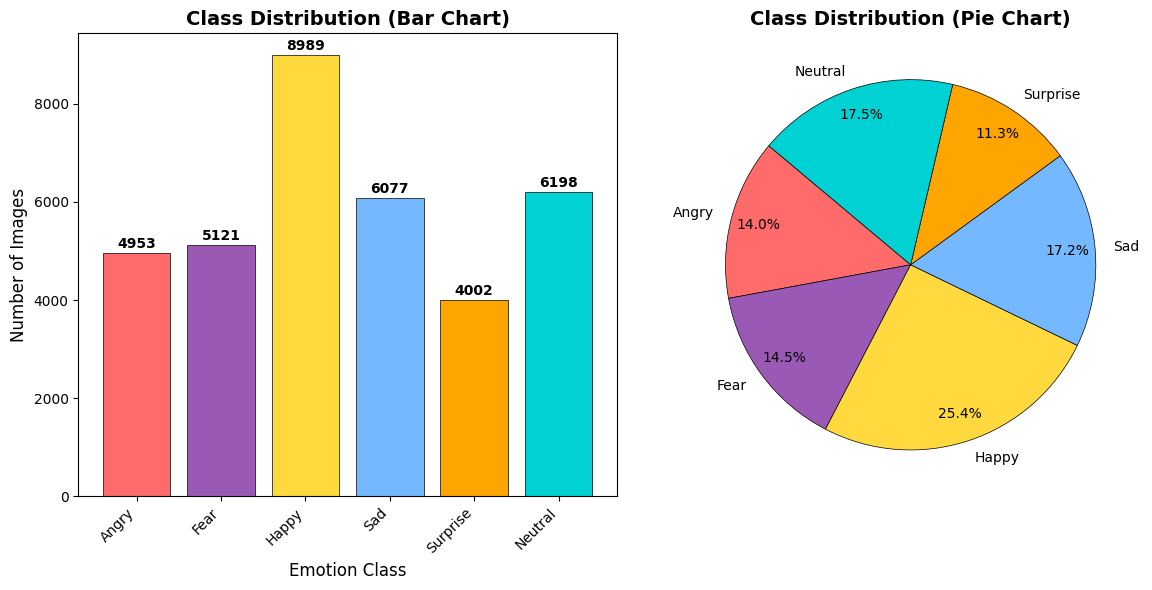

Chart saved as class_distribution.png


In [11]:
# Visualization: Bar chart of class distribution
labels = list(class_counts.keys())
values = list(class_counts.values())
colors = ['#FF6B6B', '#9B59B6', '#FFD93D', '#74B9FF', '#FFA502', '#00D2D3']

plt.figure(figsize=(12, 6))

# Bar chart
plt.subplot(1, 2, 1)
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('Emotion Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, pctdistance=0.85,
        wedgeprops=dict(edgecolor='black', linewidth=0.5))
plt.title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as class_distribution.png')

---
## 7. Sample Images from Each Class

Below we display **5 sample images** from each emotion class to visually verify the dataset.

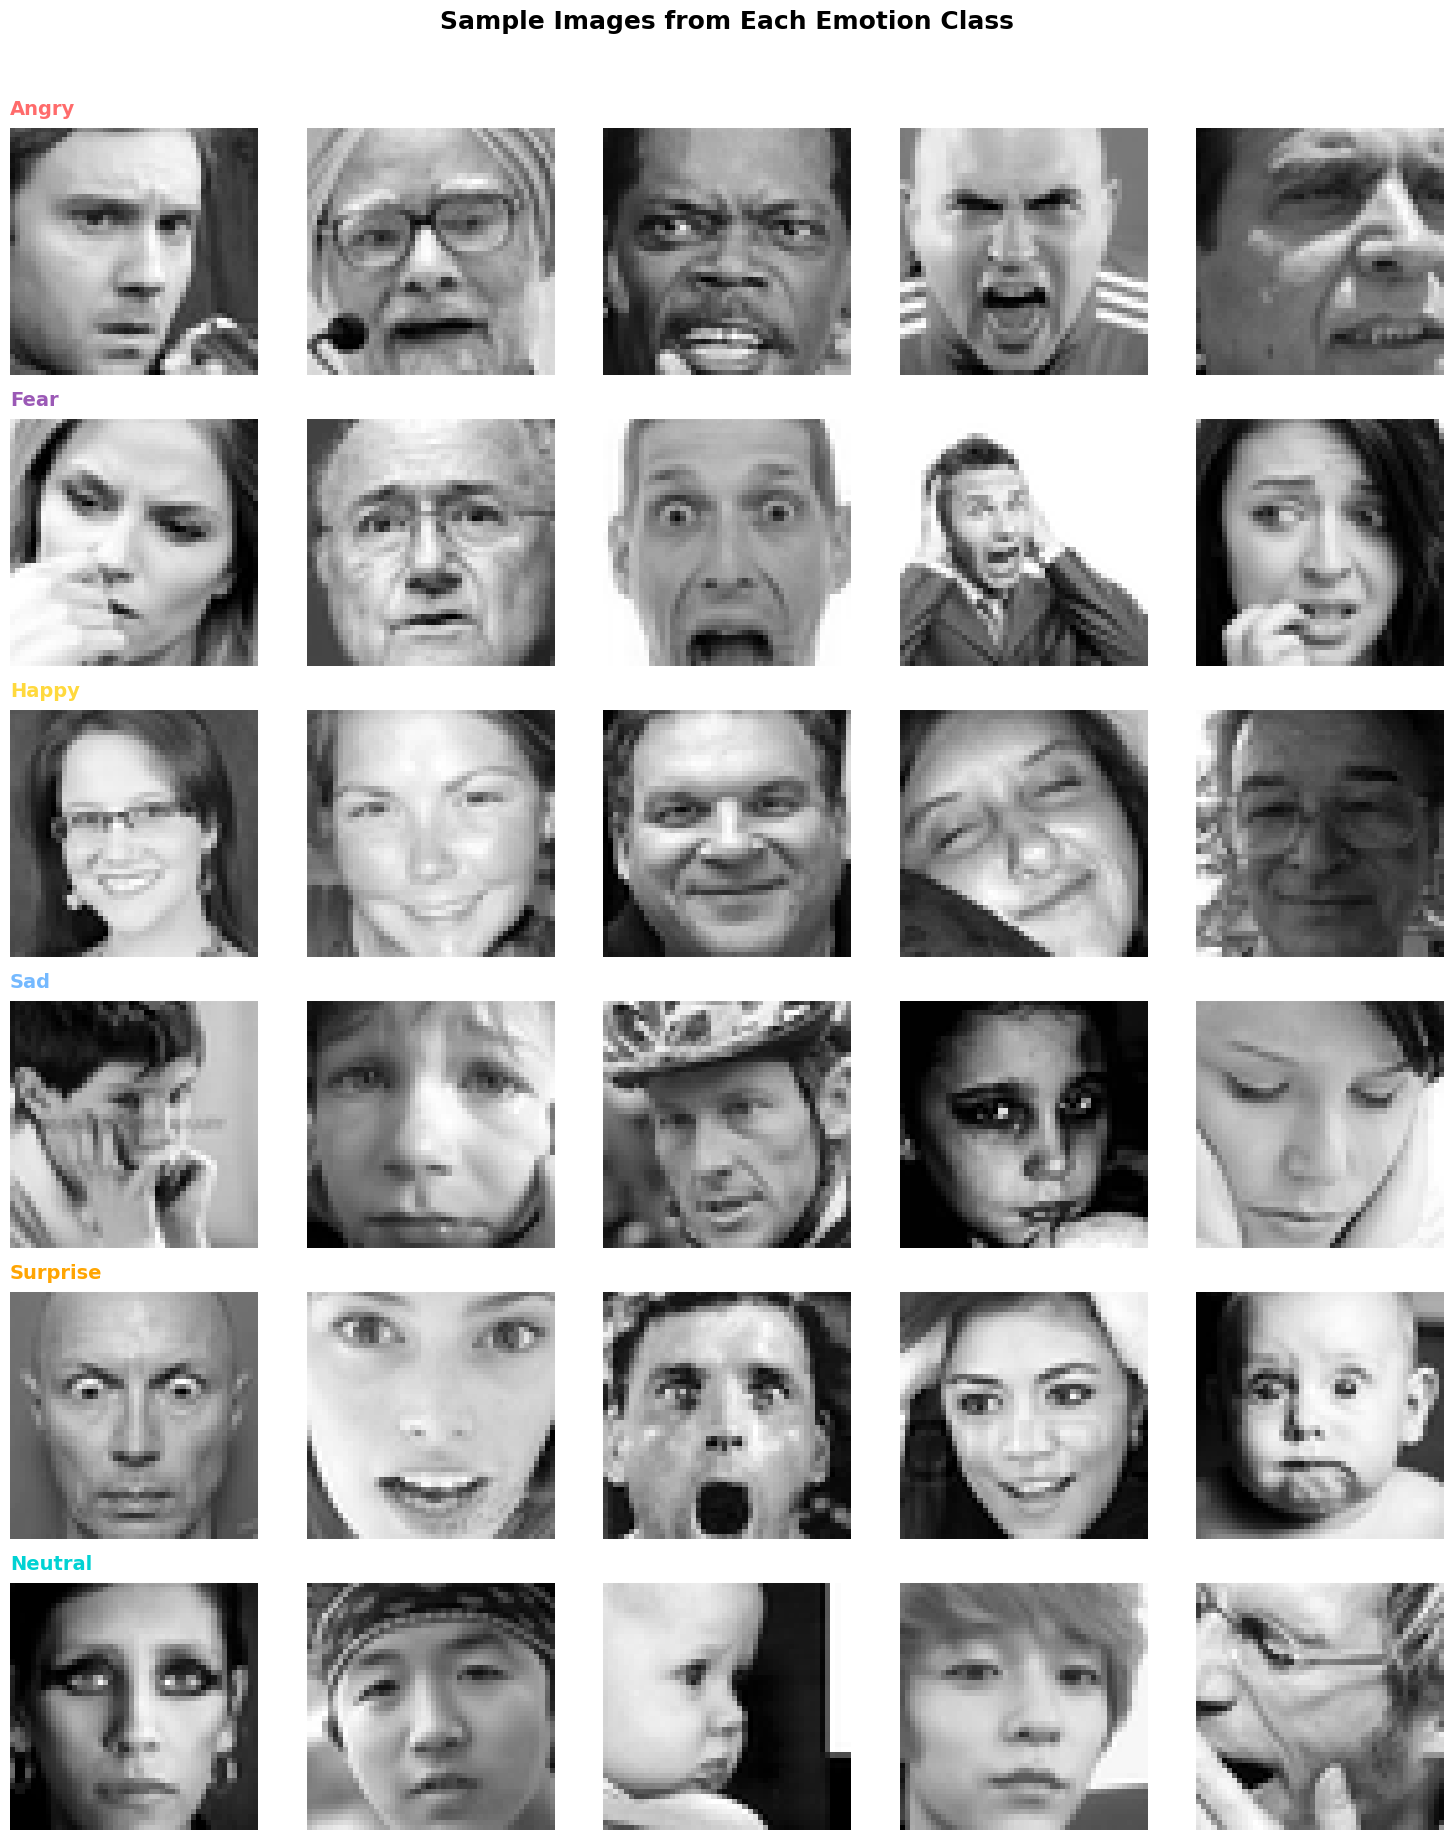

Sample images saved as sample_images.png


In [12]:
# Display 5 sample images from each class
num_samples = 5
num_classes = len(EMOTION_LABELS)

fig, axes = plt.subplots(num_classes, num_samples, figsize=(15, 18))
fig.suptitle('Sample Images from Each Emotion Class', fontsize=18, fontweight='bold', y=1.02)

for row, (label_id, label_name) in enumerate(EMOTION_LABELS.items()):
    folder = os.path.join(OUTPUT_DIR, label_name)
    files = sorted([f for f in os.listdir(folder) if f.endswith('.png')])[:num_samples]
    
    for col, fname in enumerate(files):
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'{label_name}', fontsize=14, fontweight='bold',
                                      loc='left', pad=10, color=colors[row])

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample images saved as sample_images.png')

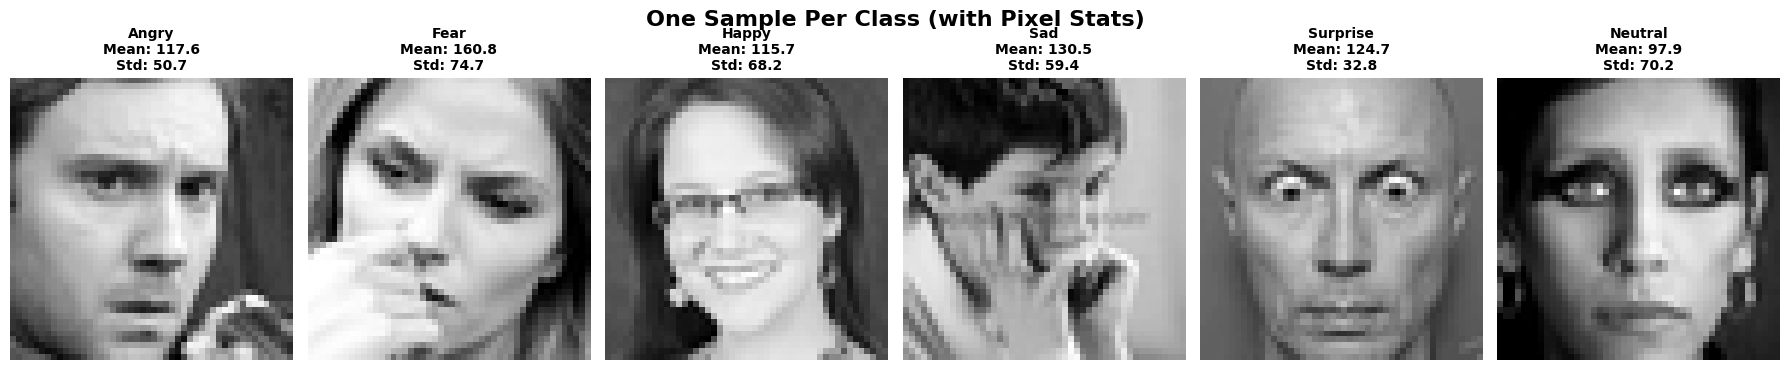

In [13]:
# Display a detailed view: 1 large sample per class with pixel statistics
fig, axes = plt.subplots(1, num_classes, figsize=(18, 4))
fig.suptitle('One Sample Per Class (with Pixel Stats)', fontsize=16, fontweight='bold')

for i, (label_id, label_name) in enumerate(EMOTION_LABELS.items()):
    folder = os.path.join(OUTPUT_DIR, label_name)
    files = sorted([f for f in os.listdir(folder) if f.endswith('.png')])
    img = cv2.imread(os.path.join(folder, files[0]), cv2.IMREAD_GRAYSCALE)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{label_name}\nMean: {img.mean():.1f}\nStd: {img.std():.1f}',
                       fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---
## 8. Summary

| Item | Details |
|---|---|
| **Dataset** | FER-2013 from Kaggle |
| **Classification Type** | Multi-class (6 classes) |
| **Class Labels** | Angry, Fear, Happy, Sad, Surprise, Neutral |
| **Image Size** | 48 × 48 pixels (Grayscale) |
| **Organized Into** | `data/organized/<ClassName>/` folders |
| **Libraries Used** | OpenCV, PIL (Pillow), Matplotlib, Pandas, NumPy |
| **Balance Status** | Moderate imbalance — Happy class is the largest |